# Compute the stable islands

We will compute the boundary of stable islands numerically checking only for long times before escape.
Let's take this as a test, and we acknowledge that the phenomenon of KAM stickiness means that the actual boundary found will probably be outside the outer IRC, and might have an irregular shape.
Let's see how bad it is and then we can maybe test other methods. 

In [8]:
from src.integrator.integrate import FastSitnikovSimulation
import numpy as np
import matplotlib.pyplot as plt

from src.analysis.stable_islands import outer_irc_point_stable_island


In [ ]:

# Example interior seed (replace with your trusted interior point).
E = 0.5
p0 = (0.25, 0.10)

result_plus = outer_irc_point_stable_island(
    e=E,
    p0=p0,
    positive_v_search=True,
    expected_dist=None,
    max_crossings=50,
    dist_error=1e-3,
    max_iterations=20,
)

print("positive direction:", result_plus)

result_minus = outer_irc_point_stable_island(
    e=E,
    p0=p0,
    positive_v_search=False,
    expected_dist=None,
    max_crossings=50,
    dist_error=1e-3,
    max_iterations=20,
)

print("negative direction:", result_minus)

positive direction: {'point': (2.251472143266674, 0.1), 'distance_estimate': 0.00044756955, 'status': 'converged', 'bracket': (2.251472143266674, 2.251919712816674)}


ValueError: Search went below v=0, which is not allowed. Check the search direction and expected_dist.

Boundary point: (2.251472143266674, 0.1)
Crossings plotted for the computed p_bound
Boundary point: (2.251472143266674, 0.1)
Crossings plotted for the shifted p_bound


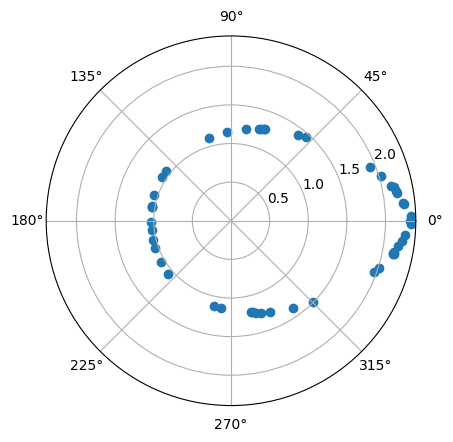

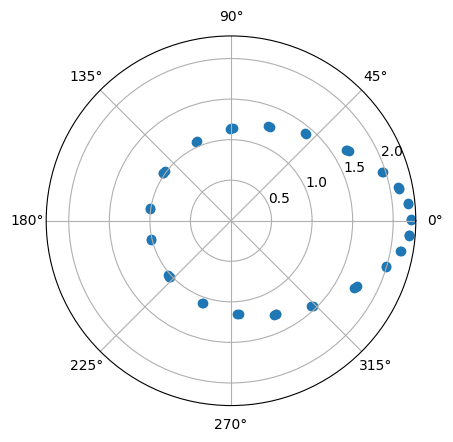

In [32]:
p_bound = result_plus['point']
print("Boundary point:", p_bound)

N_crossings = 50
crossings_t = np.zeros(N_crossings)
crossings_v = np.zeros(N_crossings)

E = 0.5
sim = FastSitnikovSimulation(e = E)
p_curr = p_bound
for i in range(N_crossings):
    # Compute crossings for the boundary point and store in crossings_arr_irc
    p_curr = sim.phi_fast(v = p_curr[0], t = p_curr[1])
    crossings_t[i] = p_curr[1]
    crossings_v[i] = p_curr[0]

from src.utils.plotting import polar_scatter

print("Crossings plotted for the computed p_bound")

fig, ax = polar_scatter(crossings_t, crossings_v)

p_bound = result_plus['point']
print("Boundary point:", p_bound)
p_bound = (p_bound[0] - 0.06, p_bound[1])  


N_crossings = 50
crossings_t = np.zeros(N_crossings)
crossings_v = np.zeros(N_crossings)

E = 0.5
sim = FastSitnikovSimulation(e = E)
p_curr = p_bound
for i in range(N_crossings):
    # Compute crossings for the boundary point and store in crossings_arr_irc
    p_curr = sim.phi_fast(v = p_curr[0], t = p_curr[1])
    crossings_t[i] = p_curr[1]
    crossings_v[i] = p_curr[0]

from src.utils.plotting import polar_scatter

print("Crossings plotted for the shifted p_bound")

fig, ax = polar_scatter(crossings_t, crossings_v)



#### You can tell from the plots that the outer boundary detected has a pattern of motion which is markedly irregular. This is aligned with the idea that the motion there is KAM sticky but not quasi-periodic. 
#### The distance to quasi-periodic motion in this case is around 0.05, which is decently low, but not lower that the desired error of 1e-3.

In [2]:
from scipy.optimize import root

E = 0.5
t_fixed = np.pi
v0 = 1.5

sim = FastSitnikovSimulation(e=E)

def fixed_point_residual(v_arr):
    v = float(v_arr[0])
    _, t_next = sim.phi_fast(v=v, t=t_fixed, return_mod_period=False)
    return np.array([t_next - t_fixed - 2*np.pi])

sol = root(fixed_point_residual, x0=np.array([v0]), method="hybr")

v_star = float(sol.x[0])
v_next, t_next = sim.phi_fast(v=v_star, t=t_fixed)

print(f"success: {sol.success}")
print(f"message: {sol.message}")
print(f"iterations (nfev): {sol.nfev}")
print(f"v*: {v_star:.15f}")
print(f"phi_fast(v*, pi) = ({v_next:.15f}, {t_next:.15f})")
print(f"residual v_next - v*: {v_next - v_star:.3e}")
print(f"t_next - pi: {t_next - np.pi:.3e}")

success: True
message: The solution converged.
iterations (nfev): 12
v*: 1.320900969141884
phi_fast(v*, pi) = (1.320900949152417, 3.141592653591127)
residual v_next - v*: -1.999e-08
t_next - pi: 1.334e-12


In [4]:
p_second_center = (v_star, t_fixed)

result_second_island = outer_irc_point_stable_island(e = 0.5, p0=p_second_center, positive_v_search=True, expected_dist=None, max_crossings=50, dist_error=1e-3, max_iterations=20)

print("Result for second center:", result_second_island)

Result for second center: {'point': (1.3417742191418847, 3.141592653589793), 'distance_estimate': 0.0004117499999999966, 'status': 'converged', 'bracket': (1.3417742191418847, 1.3421859691418847)}


Boundary point: (1.3417742191418847, 3.141592653589793)
Crossings plotted for the computed p_bound


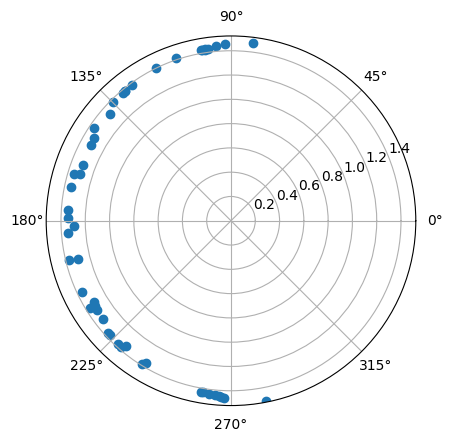

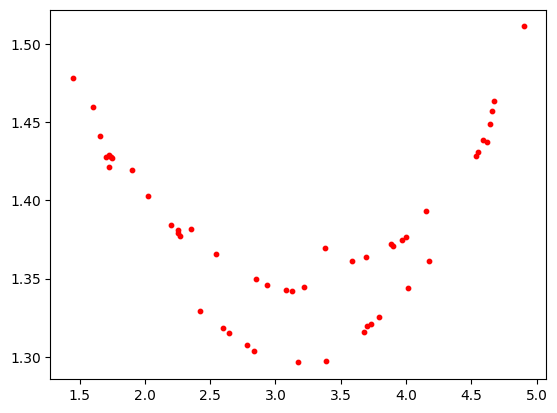

Boundary point: (1.3417742191418847, 3.141592653589793)
Crossings plotted for the shifted p_bound


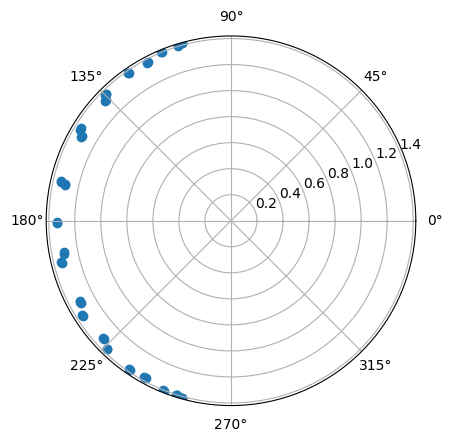

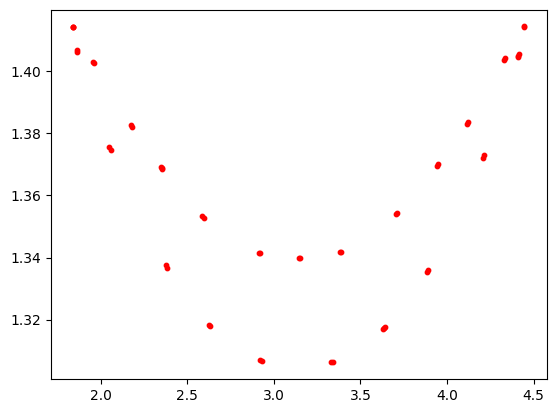

In [15]:
p_bound = result_second_island['point']
print("Boundary point:", p_bound)

N_crossings = 50
crossings_t = np.zeros(N_crossings)
crossings_v = np.zeros(N_crossings)

E = 0.5
sim = FastSitnikovSimulation(e = E)
p_curr = p_bound
for i in range(N_crossings):
    # Compute crossings for the boundary point and store in crossings_arr_irc
    p_curr = sim.phi_fast(v = p_curr[0], t = p_curr[1])
    crossings_t[i] = p_curr[1]
    crossings_v[i] = p_curr[0]

from src.utils.plotting import polar_scatter

print("Crossings plotted for the computed p_bound")

fig, ax = polar_scatter(crossings_t, crossings_v)
plt.show()
plt.scatter(crossings_t, crossings_v, color='red', s=10, label='Boundary Crossings')
plt.show()

p_bound = result_second_island['point']
print("Boundary point:", p_bound)
eps = 0.1
p_bound = ((1-eps)*p_bound[0] + eps*v_star, p_bound[1])


N_crossings = 50
crossings_t = np.zeros(N_crossings)
crossings_v = np.zeros(N_crossings)

E = 0.5
sim = FastSitnikovSimulation(e = E)
p_curr = p_bound
for i in range(N_crossings):
    # Compute crossings for the boundary point and store in crossings_arr_irc
    p_curr = sim.phi_fast(v = p_curr[0], t = p_curr[1])
    crossings_t[i] = p_curr[1]
    crossings_v[i] = p_curr[0]

from src.utils.plotting import polar_scatter

print("Crossings plotted for the shifted p_bound")

fig, ax = polar_scatter(crossings_t, crossings_v)
plt.show()
plt.scatter(crossings_t, crossings_v, color='red', s=10, label='Boundary Crossings')
plt.show()



Boundary point: (1.3417742191418847, 3.141592653589793)
Crossings plotted for the shifted p_bound


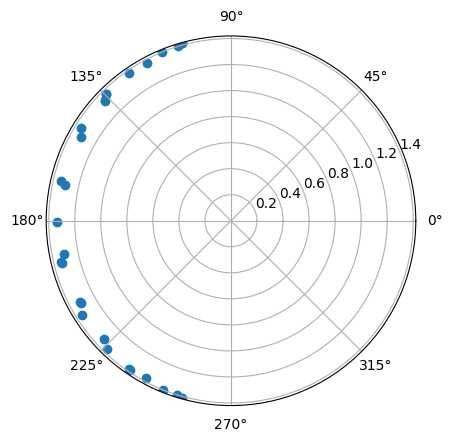

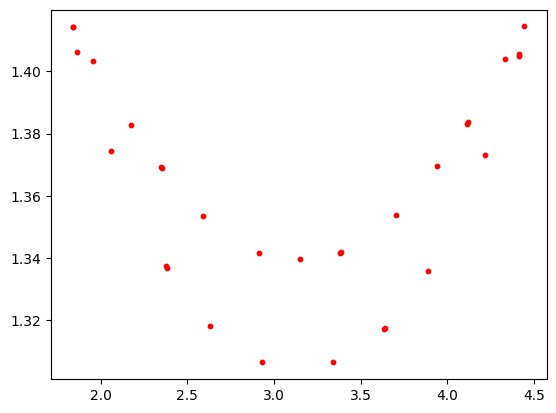

In [25]:
p_bound = result_second_island['point']
print("Boundary point:", p_bound)
eps = 0.1
p_bound = ((1-eps)*p_bound[0] + eps*v_star, p_bound[1])


N_crossings = 30
crossings_t = np.zeros(N_crossings)
crossings_v = np.zeros(N_crossings)

E = 0.5
sim = FastSitnikovSimulation(e = E)
p_curr = p_bound
for i in range(N_crossings):
    # Compute crossings for the boundary point and store in crossings_arr_irc
    p_curr = sim.phi_fast(v = p_curr[0], t = p_curr[1])
    crossings_t[i] = p_curr[1]
    crossings_v[i] = p_curr[0]

from src.utils.plotting import polar_scatter

print("Crossings plotted for the shifted p_bound")

fig, ax = polar_scatter(crossings_t, crossings_v)
plt.show()
plt.scatter(crossings_t, crossings_v, color='red', s=10, label='Boundary Crossings')
plt.show()

In [ ]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import src.utils.curve_ordering as curve_ordering
importlib.reload(curve_ordering)


# Unordered cloud from previous cells
t = np.asarray(crossings_t)
v = np.asarray(crossings_v)

# Reusable helper: order cloud (NN + 2-opt) and fit periodic spline
fit = curve_ordering.fit_closed_curve_from_cloud(
    t,
    v,
    n_starts=None,      # None = try all starts for robustness
    max_passes=20,      # 2-opt refinement passes
    spline_degree=3,    # cubic spline
    smoothing=1e-2,     # smoothing factor
    n_eval=1000,        # smooth curve samples
)

# Read back outputs
points = fit["points"]
t_ord = fit["t_ord"]
v_ord = fit["v_ord"]
t_smooth = fit["t_smooth"]
v_smooth = fit["v_smooth"]

# Close polyline for display
t_ord_closed = np.r_[t_ord, t_ord[0]]
v_ord_closed = np.r_[v_ord, v_ord[0]]

plt.figure(figsize=(6, 5))
plt.scatter(points[:, 0], points[:, 1], s=10, alpha=0.35, label="unordered cloud")
plt.plot(t_ord_closed, v_ord_closed, "k--", lw=1.0, alpha=0.8, label="NN+2opt ordered points")
plt.plot(t_smooth, v_smooth, "r-", lw=2.0, label="fitted curve")
plt.xlabel("t")
plt.ylabel("v")
plt.legend()
plt.show()

print(f"NN length: {fit['length_nn']:.4f}")
print(f"NN+2opt length: {fit['length_refined']:.4f}")

ValueError: First and last points does not match which is required for `bc_type='periodic'`.